# Week 5 — Battery SoC time-series forecasting

This notebook uses the 10,000-row Week 3/4 telemetry Parquet at its native 1 Hz cadence. It performs decomposition, lets the ADF p-value determine differencing order `d`, uses ACF and PACF to select candidate `p` and `q`, and evaluates an ARIMA forecast on the final chronological 20% against a naive persistence baseline. No rows are shuffled and no anomaly label is required.

In [1]:
from pathlib import Path

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

from W05_Predictive_Models import (
    calculate_forecast_metrics,
    chronological_split,
    fit_arima_forecaster,
    forecast_with_confidence_interval,
    naive_persistence_forecast,
    run_adf_test,
    select_arima_order,
)

PARQUET_PATH = Path("outputs/profile_cleaned_features.parquet")
df = pd.read_parquet(PARQUET_PATH)
timestamp_deltas_ms = df["timestamp_ms"].diff().dropna()

assert df.shape == (10_000, 27)
assert df["timestamp_ms"].is_monotonic_increasing
assert df["timestamp_ms"].is_unique
assert timestamp_deltas_ms.eq(1_000).all()
assert df.isna().sum().eq(0).all()

time_index = pd.DatetimeIndex(
    pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True),
    freq="s",
    name="timestamp",
)
battery_soc = pd.Series(
    df["battery_soc"].to_numpy(dtype=float),
    index=time_index,
    name="battery_soc",
)
wheel_columns = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
]
mean_wheel_torque = pd.Series(
    df[wheel_columns].mean(axis=1).to_numpy(dtype=float),
    index=time_index,
    name="mean_wheel_torque",
)

print(f"Source: {PARQUET_PATH.resolve()}")
print(f"n = {len(df):,}; columns = {df.shape[1]}; cadence = 1 Hz")
print("Chronological coverage: 9,999 seconds; missing values: 0")

Source: C:\ingen\outputs\profile_cleaned_features.parquet
n = 10,000; columns = 27; cadence = 1 Hz
Chronological coverage: 9,999 seconds; missing values: 0


## 1. Additive decomposition

Battery SoC uses a 60-second diagnostic period to separate local movement from residual shocks. Mean wheel torque uses a 5,000-second period, matching the slow two-cycle structure visible over the 10,000-second synthetic profile.

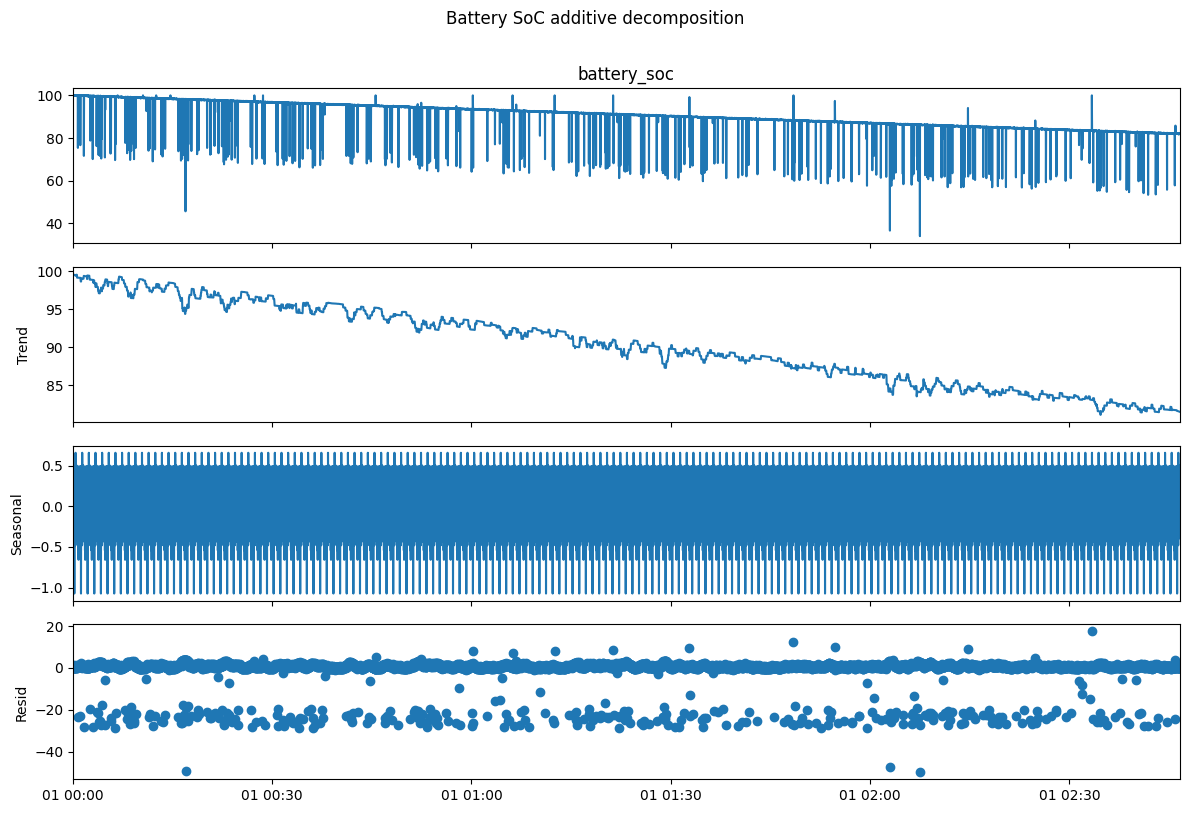

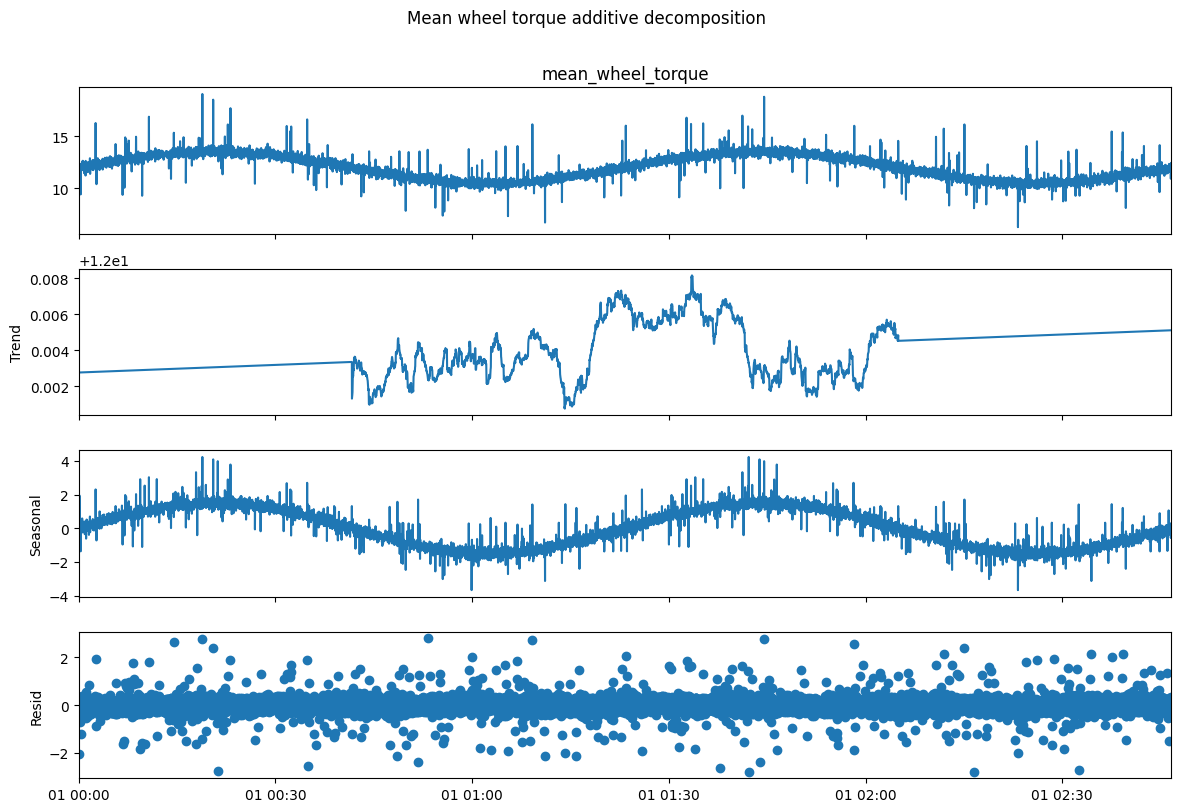

In [2]:
battery_decomposition = seasonal_decompose(
    battery_soc,
    model="additive",
    period=60,
    extrapolate_trend="freq",
)
wheel_decomposition = seasonal_decompose(
    mean_wheel_torque,
    model="additive",
    period=5_000,
    extrapolate_trend="freq",
)

for title, decomposition in (
    ("Battery SoC additive decomposition", battery_decomposition),
    ("Mean wheel torque additive decomposition", wheel_decomposition),
):
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()

## 2. ADF determines differencing order

The differencing order is not assumed. The original `battery_soc` series is tested first. Only when its ADF p-value is at least 0.05 is the series differenced once and the differenced series tested.

In [3]:
ADF_ALPHA = 0.05
raw_adf = run_adf_test(battery_soc, alpha=ADF_ALPHA)
d = 0 if raw_adf.rejected else 1
decision = "rejected" if raw_adf.rejected else "not rejected"

print("Original battery_soc ADF")
print(f"  statistic = {raw_adf.statistic:.6f}")
print(f"  p-value   = {raw_adf.p_value:.6f}")
print(f"  n         = {raw_adf.nobs:,}")
print(
    f"The ADF test returned p = {raw_adf.p_value:.6f}, so the "
    f"unit-root null was {decision}. Therefore, differencing order "
    f"d = {d} was used."
)

if d == 1:
    stationary_series = battery_soc.diff().dropna()
    differenced_adf = run_adf_test(stationary_series, alpha=ADF_ALPHA)
    print("\nDifferenced battery_soc ADF")
    print(f"  statistic = {differenced_adf.statistic:.6f}")
    print(f"  p-value   = {differenced_adf.p_value:.6g}")
    print(f"  n         = {differenced_adf.nobs:,}")
    assert differenced_adf.rejected
else:
    stationary_series = battery_soc
    differenced_adf = None

assert d == (0 if raw_adf.p_value < ADF_ALPHA else 1)

Original battery_soc ADF
  statistic = -2.319326
  p-value   = 0.165811
  n         = 9,961
The ADF test returned p = 0.165811, so the unit-root null was not rejected. Therefore, differencing order d = 1 was used.



Differenced battery_soc ADF
  statistic = -26.743806
  p-value   = 0
  n         = 9,960


## 3. ACF and PACF order diagnostics

The 95% white-noise bounds are ±1.96/√n. A finite PACF cutoff supplies candidate `p`; a finite ACF cutoff supplies candidate `q`. A diagnostic that remains significant through the short-order search window is treated as a tail rather than a finite cutoff.

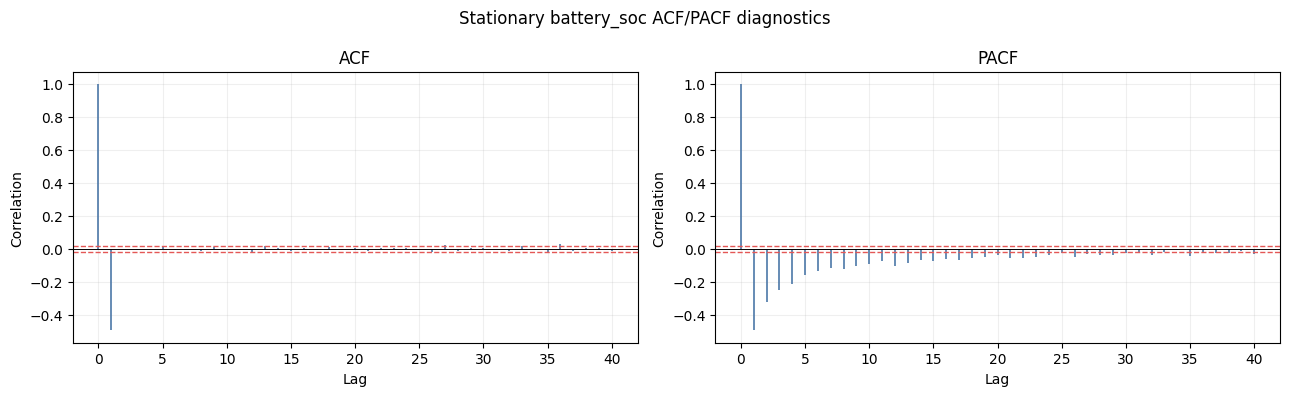

ACF short-lag cutoff: 1
PACF short-lag cutoff: None
Final ARIMA order = (0, 1, 1)


In [4]:
order_diagnostics = select_arima_order(
    stationary_series,
    d=d,
    nlags=40,
    max_order=5,
)
arima_order = order_diagnostics.order
lags = np.arange(len(order_diagnostics.acf_values))
bound = order_diagnostics.significance_threshold

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, values, title in (
    (axes[0], order_diagnostics.acf_values, "ACF"),
    (axes[1], order_diagnostics.pacf_values, "PACF"),
):
    ax.vlines(lags, 0.0, values, color="#4C78A8", linewidth=1.2)
    ax.axhline(bound, color="#E45756", linestyle="--", linewidth=1)
    ax.axhline(-bound, color="#E45756", linestyle="--", linewidth=1)
    ax.axhline(0.0, color="black", linewidth=0.7)
    ax.set(title=title, xlabel="Lag", ylabel="Correlation")
    ax.grid(alpha=0.2)
fig.suptitle("Stationary battery_soc ACF/PACF diagnostics")
fig.tight_layout()
plt.show()

print(f"ACF short-lag cutoff: {order_diagnostics.acf_cutoff}")
print(f"PACF short-lag cutoff: {order_diagnostics.pacf_cutoff}")
print(f"Final ARIMA order = {arima_order}")
assert arima_order[1] == d

## 4. Chronological forecast and naive comparison

The first 80% is training data and the final 20% is the untouched test window. The ARIMA and naive persistence forecasts both cover every test timestamp. The reported interval is the ARIMA model's 95% forecast confidence interval.

In [5]:
train, test = chronological_split(battery_soc, train_fraction=0.80)
fitted_arima = fit_arima_forecaster(train, arima_order)
arima_forecast = forecast_with_confidence_interval(
    fitted_arima,
    steps=len(test),
    index=test.index,
    alpha=0.05,
)
naive_forecast = naive_persistence_forecast(train, test)

arima_metrics = calculate_forecast_metrics(test, arima_forecast.mean)
naive_metrics = calculate_forecast_metrics(test, naive_forecast)
metrics_table = pd.DataFrame(
    [arima_metrics, naive_metrics],
    index=["ARIMA", "Naive persistence"],
).rename(columns={"rmse": "RMSE", "mae": "MAE"})

assert len(train) == 8_000
assert len(test) == 2_000
assert len(arima_forecast.mean) == len(test)
assert arima_forecast.mean.index.equals(test.index)
assert arima_forecast.confidence_interval.shape == (len(test), 2)
assert arima_forecast.confidence_interval.index.equals(test.index)
assert len(naive_forecast) == len(test)

print(f"Final ARIMA order = {arima_order}")
print(f"train n = {len(train):,}; test n = {len(test):,}")
print(
    f"ARIMA RMSE = {arima_metrics['rmse']:.6f}; "
    f"ARIMA MAE = {arima_metrics['mae']:.6f}"
)
print(
    f"Naive RMSE = {naive_metrics['rmse']:.6f}; "
    f"Naive MAE = {naive_metrics['mae']:.6f}"
)
print(
    "95% forecast confidence interval shape: "
    f"{arima_forecast.confidence_interval.shape}"
)
display(metrics_table.round(6))

forecast_table = pd.concat(
    [
        test.rename("actual"),
        arima_forecast.mean,
        arima_forecast.confidence_interval,
        naive_forecast,
    ],
    axis=1,
)
print("95% forecast confidence interval — first 5 rows")
display(forecast_table.head())
print("95% forecast confidence interval — final 5 rows")
display(forecast_table.tail())

Final ARIMA order = (0, 1, 1)
train n = 8,000; test n = 2,000
ARIMA RMSE = 4.493760; ARIMA MAE = 1.968800
Naive RMSE = 4.748149; Naive MAE = 2.423951
95% forecast confidence interval shape: (2000, 2)


,RMSE,MAE
ARIMA,4.493760,1.968800
Naive persistence,4.748149,2.423951


95% forecast confidence interval — first 5 rows


,actual,forecast,lower_95,upper_95,naive_persistence
timestamp,,,,,
2025-01-01 02:13:20+00:00,85.527175,84.99341,75.881645,94.105174,85.54878
2025-01-01 02:13:21+00:00,85.573859,84.99341,75.881286,94.105533,85.54878
2025-01-01 02:13:22+00:00,85.490357,84.99341,75.880927,94.105892,85.54878
2025-01-01 02:13:23+00:00,85.609917,84.99341,75.880568,94.106252,85.54878
2025-01-01 02:13:24+00:00,85.302011,84.99341,75.880208,94.106611,85.54878


95% forecast confidence interval — final 5 rows


,actual,forecast,lower_95,upper_95,naive_persistence
timestamp,,,,,
2025-01-01 02:46:35+00:00,81.885100,84.99341,75.190963,94.795857,85.54878
2025-01-01 02:46:36+00:00,81.873874,84.99341,75.190629,94.796191,85.54878
2025-01-01 02:46:37+00:00,82.186794,84.99341,75.190295,94.796525,85.54878
2025-01-01 02:46:38+00:00,81.892547,84.99341,75.189961,94.796858,85.54878
2025-01-01 02:46:39+00:00,81.953732,84.99341,75.189627,94.797192,85.54878


C:\Users\32408\AppData\Local\Temp\ipykernel_28572\734164108.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(


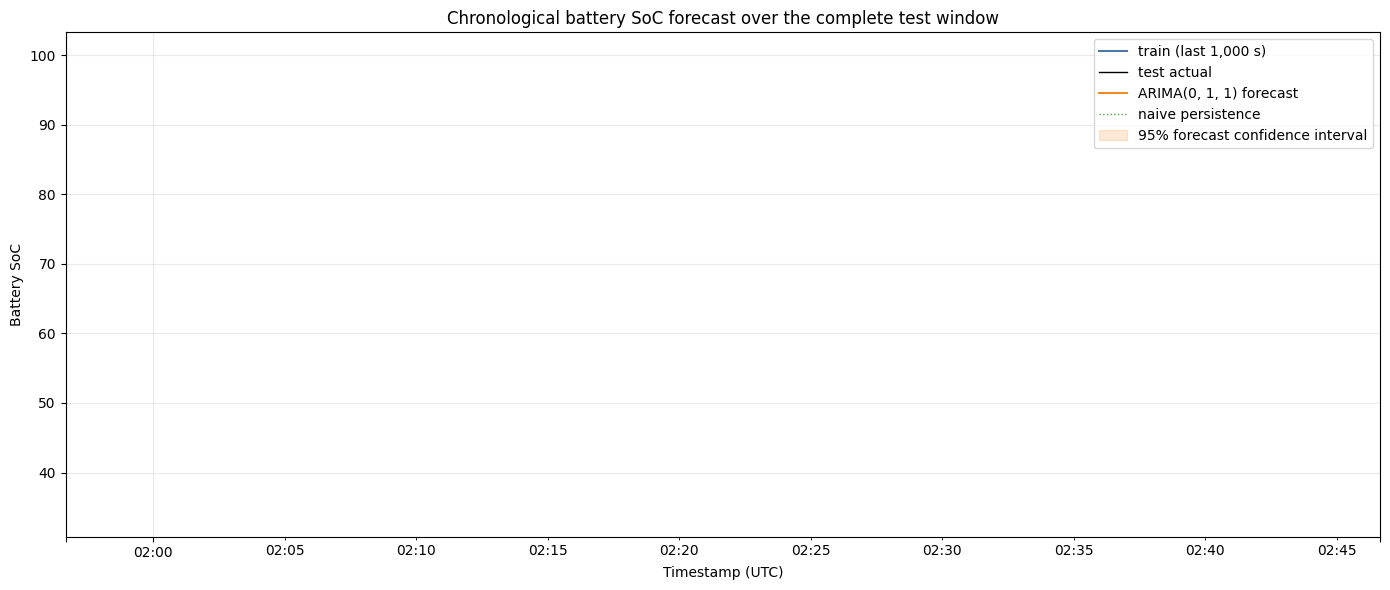

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
train.tail(1_000).plot(ax=ax, color="#4C78A8", label="train (last 1,000 s)")
test.plot(ax=ax, color="black", linewidth=1.0, label="test actual")
arima_forecast.mean.plot(
    ax=ax,
    color="#F58518",
    linewidth=1.4,
    label=f"ARIMA{arima_order} forecast",
)
ax.plot(
    test.index,
    naive_forecast,
    color="#54A24B",
    linewidth=1.0,
    linestyle=":",
    label="naive persistence",
)
ax.fill_between(
    test.index,
    arima_forecast.confidence_interval["lower_95"],
    arima_forecast.confidence_interval["upper_95"],
    color="#F58518",
    alpha=0.18,
    label="95% forecast confidence interval",
)
ax.axvline(test.index[0], color="gray", linestyle="--", linewidth=1)
ax.set(
    title="Chronological battery SoC forecast over the complete test window",
    xlabel="Timestamp (UTC)",
    ylabel="Battery SoC",
)
ax.legend(loc="best")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Interpretation

This is a fixed-origin 2,000-step forecast. It measures long-horizon extrapolation from the end of the training window, not rolling one-step-ahead updating. The naive baseline uses only the final training observation, while ARIMA uses the data-driven `(p, d, q)` order selected above.